# Notebook for constructing age models for the Cut Face Creek Sandstone

In [16]:
using Pkg
Pkg.activate("../")
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

  Activating project at `~/Github/APWP_StratModels/code`


plot_posterior_paths (generic function with 1 method)

## Cut Face Creek sandstone

- Grand Marais rhyolite constrains the bottom of the strat
- Beaver River diabase intrusion constrains the top of the strat

In [17]:
Cut_Face_Name = ("Grand Marais rhyolite", "Beaver River diabase") # Et cetera
Cut_Face_Age           = [1093.52,  1091.7] # Measured ages
Cut_Face_Age_sigma     = [0.43/2,  0.2/2] # Measured 1-σ uncertainties
Cut_Face_Height        = [0,  95.13] # Depths below surface should be negative
Cut_Face_Age_Sidedness = [0, 0] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

Cut_Face_Path = "../../data/age_models_output//Cut_Face" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
Cut_Face_section = make_ChronAgeData(Cut_Face_Name, Cut_Face_Age, Cut_Face_Age_sigma, Cut_Face_Height, Cut_Face_Age_Sidedness, Cut_Face_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{2}(("Grand Marais rhyolite", "Beaver River diabase"), [0.0, 95.13], [0.01, 0.01], [1093.52, 1091.7], [0.215, 0.1], [NaN, NaN], [NaN, NaN], [NaN, NaN], [NaN, NaN], [0.0, 0.0], [0.0, 0.0], [#undef, #undef], (:Chronometer, :Chronometer), [NaN NaN; NaN NaN; … ; NaN NaN; NaN NaN], "../../data/age_models_output//Cut_Face", 2, "Ma", "m", :cdf)

In [18]:
Cut_Face_age_model_config, Cut_Face_age_model_mdl, Cut_Face_age_model_agedist, Cut_Face_age_model_lldist = run_age_model(Cut_Face_section, 0.2, 0.2, 1000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:28
┌ Info: Burn-in: 666000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 666000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:00


(StratAgeModelConfiguration(0.2, 666000, 1000, 666, 0.2), StratAgeModel([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8  …  93.2, 93.4, 93.6, 93.8, 94.0, 94.2, 94.4, 94.6, 94.8, 95.0], [1093.5364500066553, 1093.5329162926823, 1093.5291576837, 1093.526147305976, 1093.5226016647034, 1093.5181523047947, 1093.512891891559, 1093.5099571885912, 1093.5056045785861, 1093.5019773070776  …  1091.7287089576266, 1091.7228544776053, 1091.7184603409535, 1091.7145225327354, 1091.7107951937126, 1091.7052769694246, 1091.702390557394, 1091.698238718339, 1091.6938202500808, 1091.6889926444462], [0.16883075100759037, 0.17079488628408687, 0.17228271065507503, 0.17515452495984846, 0.1772448298127446, 0.18086495560232477, 0.18592236510067736, 0.1887314681562515, 0.1909566571236762, 0.192804642756327  …  0.13409189777343258, 0.12854081694769404, 0.12340423449595679, 0.1213733870416044, 0.12001063808505831, 0.11431074749793821, 0.10979431541559785, 0.10658212659872617, 0.10095435672630323, 0.0969325846370363

### posterior summary age model

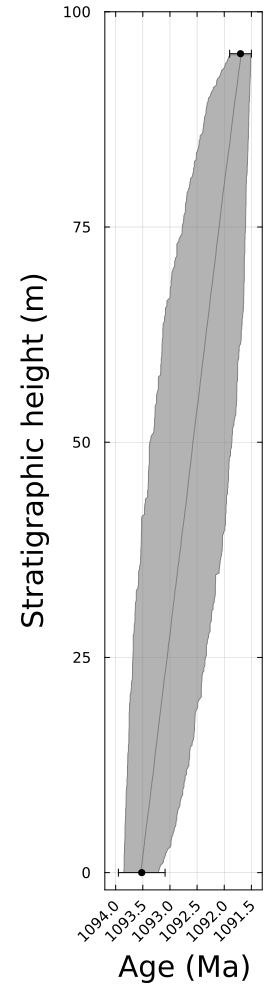

In [19]:
Cut_Face_age_model = plot_age_model(Cut_Face_section, Cut_Face_age_model_mdl, save_figure=false)
plot!(ylim=(-2, 100), xlim=(1091.3, 1094.2), legend=false, left_margin = 12Plots.mm, guidefontsize=20, size=(275, 1000))
savefig(Cut_Face_age_model, Cut_Face_section.Path*"_AgeDepthModel.pdf")

display(Cut_Face_age_model)

### example posterior accumulation models

agemin: 1091.6894572539088, agemax: 1093.5444830929898, halfw: 0.5, Δt: 0.1
Number of windows: 9
  0.011784 seconds (9.00 k allocations: 11.902 MiB)


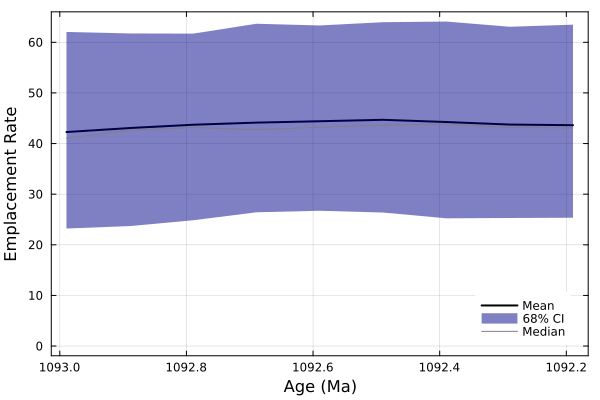

In [5]:
plot_accumulation_model(Cut_Face_section, Cut_Face_age_model_config, Cut_Face_age_model_mdl, Cut_Face_age_model_agedist, binwidth=1, stepfrac=0.1, save_figure=false)

### example posterior age models

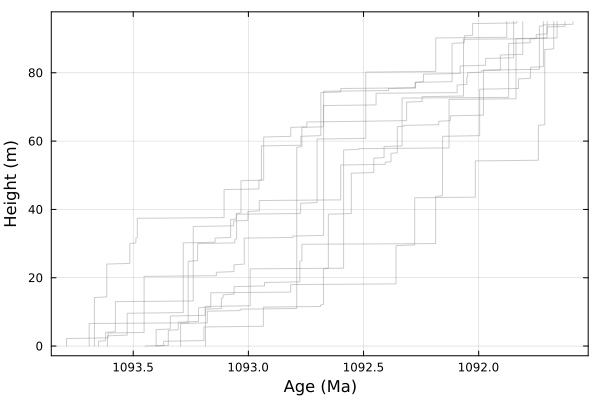

In [6]:
plot_posterior_paths(Cut_Face_section, Cut_Face_age_model_agedist, Cut_Face_age_model_mdl)

## save the age models to a file

In [7]:
Cut_Face_age_model_agedist

476×1000 Matrix{Float64}:
 1093.56  1093.64  1093.71  1093.33  …  1093.56  1093.39  1093.73  1093.6
 1093.56  1093.64  1093.71  1093.33     1093.56  1093.39  1093.73  1093.6
 1093.56  1093.64  1093.71  1093.33     1093.56  1093.39  1093.73  1093.6
 1093.56  1093.64  1093.71  1093.33     1093.56  1093.39  1093.73  1093.6
 1093.56  1093.64  1093.71  1093.33     1093.56  1093.39  1093.73  1093.6
 1093.56  1093.64  1093.71  1093.33  …  1093.56  1093.39  1093.73  1093.6
 1093.56  1093.64  1093.71  1093.33     1093.56  1093.39  1093.73  1093.6
 1093.56  1093.61  1093.71  1093.33     1093.56  1093.39  1093.73  1093.6
 1093.56  1093.61  1093.71  1093.33     1093.56  1093.39  1093.61  1093.6
 1093.56  1093.61  1093.71  1093.33     1093.56  1093.39  1093.61  1093.6
    ⋮                                ⋱                             
 1091.79  1091.82  1091.87  1091.78     1091.81  1091.74  1091.74  1091.69
 1091.79  1091.82  1091.87  1091.78     1091.81  1091.74  1091.74  1091.69
 1091.79  1091.8

In [8]:
# use the mdl.height as index, agedist as the data
Cut_Face_age_models_df = DataFrame(hcat(Cut_Face_age_model_mdl.Height, Cut_Face_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(Cut_Face_age_models_df, Dict(:x1 => "height"))
Cut_Face_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,0.0,1093.56,1093.64,1093.71,1093.33,1093.41,1093.85,1093.31,1093.53,1093.52,1093.69,1093.5,1093.46,1093.46,1093.64,1093.75,1093.25,1093.71,1093.55,1093.02,1093.22,1093.35,1093.6,1093.42,1093.35,1093.57,1093.54,1093.55,1093.35,1093.5,1093.64,1093.68,1093.57,1093.55,1093.43,1093.57,1093.58,1093.64,1093.59,1093.27,1093.3,1093.44,1093.35,1093.74,1093.65,1093.59,1093.45,1093.39,1093.72,1093.49,1093.77,1093.57,1093.62,1093.2,1093.66,1093.55,1093.51,1093.48,1093.84,1093.46,1093.56,1093.59,1093.69,1093.58,1093.44,1093.61,1093.51,1093.06,1093.61,1093.28,1093.25,1093.42,1093.48,1093.38,1093.75,1093.39,1093.81,1093.6,1093.32,1093.67,1093.81,1093.3,1093.59,1093.77,1093.47,1093.6,1093.68,1093.4,1093.62,1093.68,1093.58,1093.77,1093.45,1093.59,1093.62,1093.78,1093.51,1093.45,1093.68,1093.72,⋯
2,0.2,1093.56,1093.64,1093.71,1093.33,1093.41,1093.85,1093.31,1093.53,1093.52,1093.69,1093.5,1093.46,1093.46,1093.64,1093.75,1093.25,1093.71,1093.55,1093.02,1093.22,1093.35,1093.6,1093.42,1093.35,1093.55,1093.54,1093.55,1093.35,1093.5,1093.64,1093.68,1093.57,1093.55,1093.33,1093.57,1093.58,1093.64,1093.59,1093.27,1093.3,1093.44,1093.35,1093.74,1093.65,1093.59,1093.45,1093.39,1093.72,1093.49,1093.77,1093.57,1093.62,1093.2,1093.66,1093.55,1093.51,1093.48,1093.84,1093.46,1093.56,1093.59,1093.69,1093.58,1093.44,1093.61,1093.51,1093.06,1093.61,1093.28,1093.25,1093.42,1093.48,1093.38,1093.75,1093.39,1093.81,1093.6,1093.32,1093.67,1093.81,1093.3,1093.59,1093.77,1093.47,1093.6,1093.68,1093.34,1093.62,1093.68,1093.58,1093.77,1093.45,1093.59,1093.62,1093.78,1093.51,1093.45,1093.68,1093.72,⋯
3,0.4,1093.56,1093.64,1093.71,1093.33,1093.41,1093.85,1093.31,1093.53,1093.52,1093.69,1093.5,1093.46,1093.46,1093.64,1093.75,1093.25,1093.71,1093.55,1093.02,1093.22,1093.35,1093.6,1093.42,1093.35,1093.55,1093.54,1093.55,1093.35,1093.5,1093.64,1093.68,1093.57,1093.55,1093.33,1093.57,1093.58,1093.64,1093.59,1093.27,1093.3,1093.44,1093.35,1093.74,1093.65,1093.59,1093.45,1093.39,1093.72,1093.49,1093.77,1093.57,1093.62,1093.2,1093.66,1093.55,1093.51,1093.48,1093.84,1093.46,1093.56,1093.59,1093.69,1093.58,1093.44,1093.61,1093.51,1093.06,1093.61,1093.28,1093.25,1093.42,1093.48,1093.38,1093.75,1093.39,1093.81,1093.6,1093.32,1093.67,1093.81,1093.3,1093.59,1093.77,1093.47,1093.6,1093.68,1093.34,1093.62,1093.68,1093.58,1093.77,1093.45,1093.59,1093.62,1093.78,1093.51,1093.45,1093.68,1093.72,⋯
4,0.6,1093.56,1093.64,1093.71,1093.33,1093.41,1093.85,1093.31,1093.53,1093.52,1093.69,1093.5,1093.46,1093.46,1093.64,1093.75,1093.25,1093.71,1093.55,1093.02,1093.22,1093.35,1093.6,1093.42,1093.35,1093.55,1093.54,1093.55,1093.35,1093.5,1093.64,1093.68,1093.57,1093.55,1093.33,1093.57,1093.58,1093.64,1093.59,1093.27,1093.3,1093.44,1093.35,1093.74,1093.65,1093.59,1093.45,1093.39,1093.72,1093.49,1093.77,1093.57,1093.62,10

In [9]:
# write the DataFrame to a csv file
CSV.write(Cut_Face_section.Path*"_posterior_ages.csv", Cut_Face_age_models_df)

"../../data/age_models_output//Cut_Face_posterior_ages.csv"